In [1]:
# Q1
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

print("First 10 Rows")
print(df.head(10))

print("\nLast 5 Rows")
print(df.tail())

print("\nShape of Dataset:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nColumns:")
print(df.columns)

First 10 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy

In [ ]:
print("Missing Values")
print(df.isnull().sum())
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)
df = df.drop_duplicates()
print("\nNew Shape:")
print(df.shape)

Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows: 0

New Shape:
(891, 12)


In [ ]:
print(df.describe())
print("\nMean Values")
print(df[['Age','Fare','Pclass']].mean())
print("\nMedian Values")
print(df[['Age','Fare','Pclass']].median())
print("\nMinimum Values")
print(df[['Age','Fare','Pclass']].min())
print("\nMaximum Values")
print(df[['Age','Fare','Pclass']].max())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  

Mean Values
Age       29.699118
Fare      32.204208
Pclass     2.308642
dtype: f

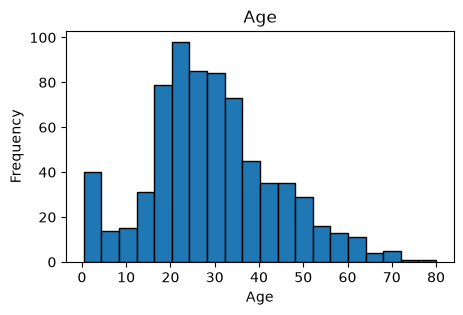

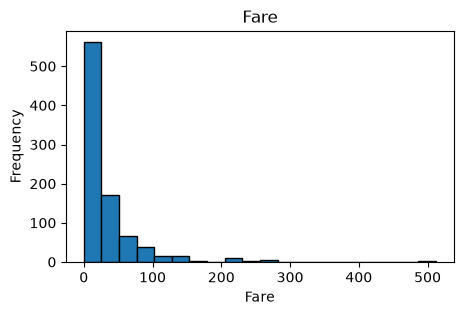

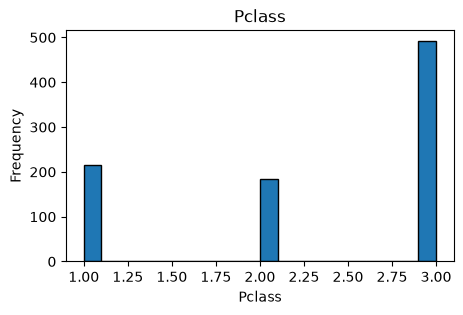

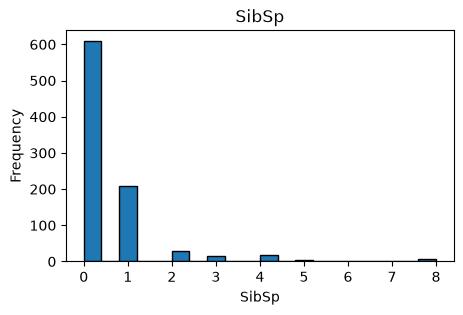

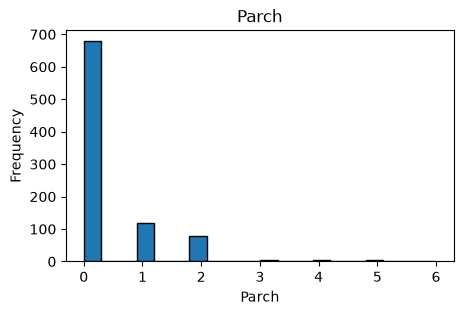

In [5]:
#Q.4)
import matplotlib.pyplot as plt
num_cols = ['Age','Fare','Pclass','SibSp','Parch']
for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.hist(df[col].dropna(), bins=20, edgecolor='black')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show() 


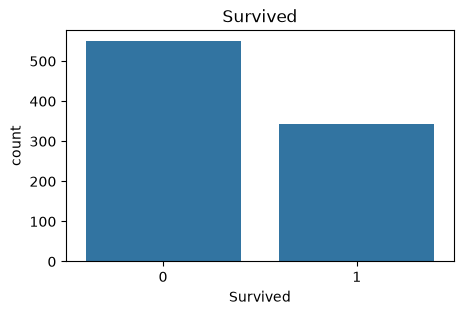

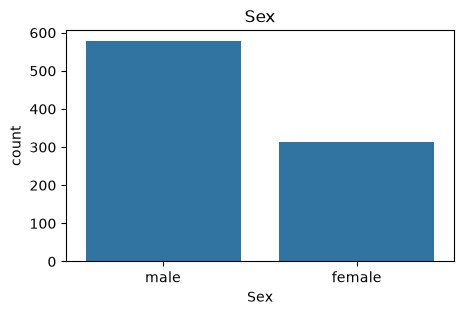

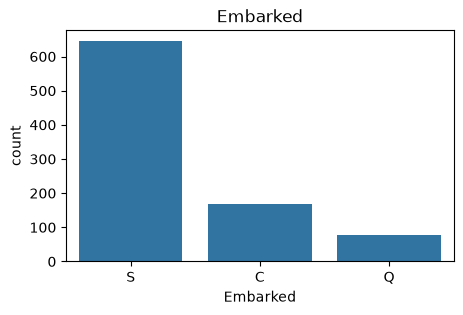

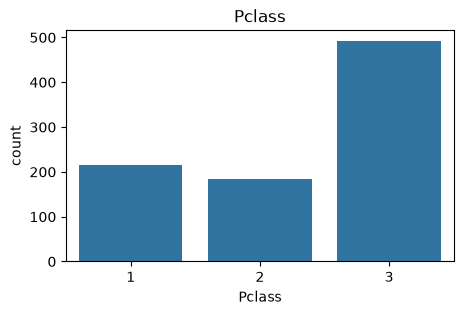

In [7]:
import seaborn as sns
cat_cols = ['Survived','Sex','Embarked','Pclass']
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(col)
    plt.show()

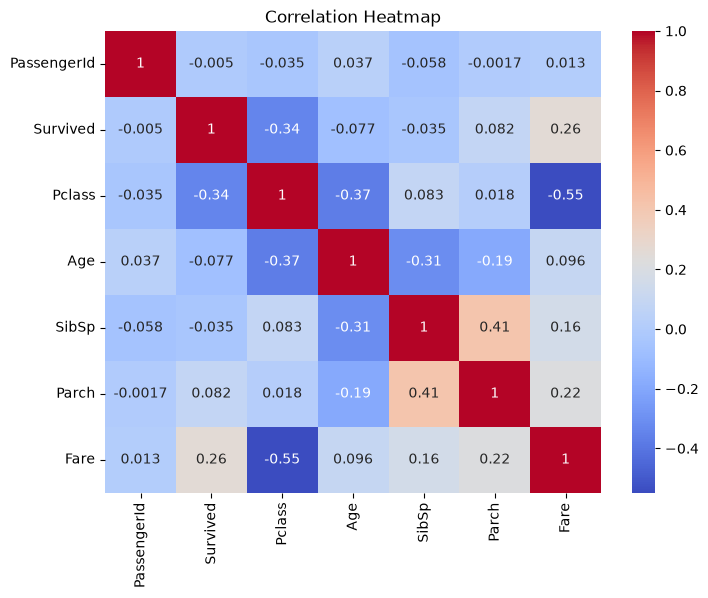

In [8]:
# Q6

plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop("Survived", axis=1)
y = df["Survived"]
print("Independent Features")
print(X.columns)
print("\nDependent Feature")
print(y.name)

Independent Features
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Dependent Feature
Survived


In [10]:
# Q8

print("Before Encoding")
print(df[['Sex','Embarked']].head())

encoded_df = pd.get_dummies(df,
                            columns=['Sex','Embarked'],
                            drop_first=True)

print("\nAfter Encoding")
print(encoded_df.head())

Before Encoding
      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S

After Encoding
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare Cabin  Sex_male  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500   NaN      True       False        True  
1          PC 17599  71.2833   C85    

In [12]:
from sklearn.preprocessing import StandardScaler
X = encoded_df.drop("Survived", axis=1)
y = encoded_df["Survived"]

X = X.select_dtypes(include=['int64','float64','bool'])
scaler = StandardScaler()
num_cols = ['Age','Fare','SibSp','Parch','Pclass']
X[num_cols] = scaler.fit_transform(X[num_cols])
print(X.head())

   PassengerId    Pclass       Age     SibSp     Parch      Fare  Sex_male  \
0            1  0.827377 -0.530377  0.432793 -0.473674 -0.502445      True   
1            2 -1.566107  0.571831  0.432793 -0.473674  0.786845     False   
2            3  0.827377 -0.254825 -0.474545 -0.473674 -0.488854     False   
3            4 -1.566107  0.365167  0.432793 -0.473674  0.420730     False   
4            5  0.827377  0.365167 -0.474545 -0.473674 -0.486337      True   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_11128\2859263821.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_11128\2859263821.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using

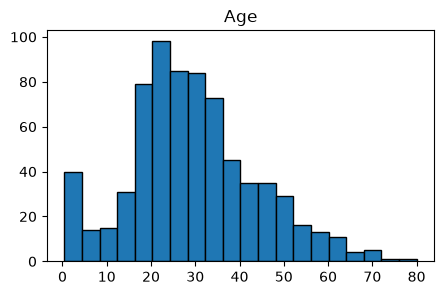

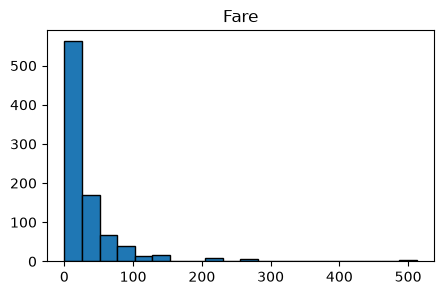

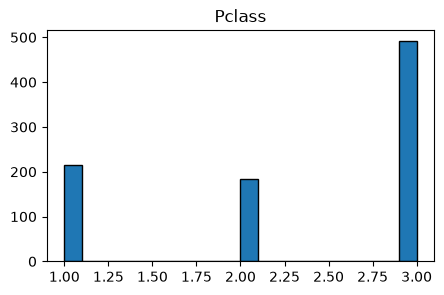

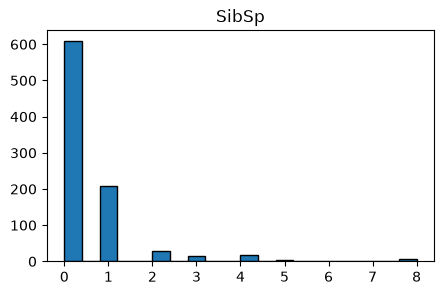

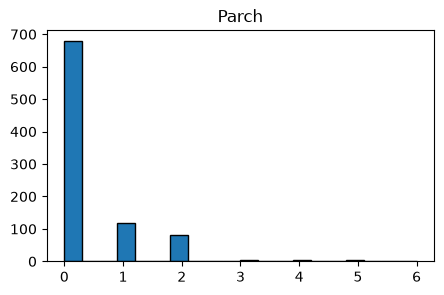

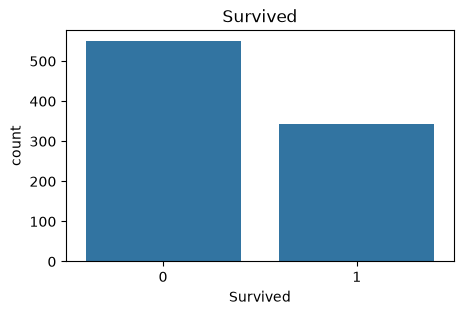

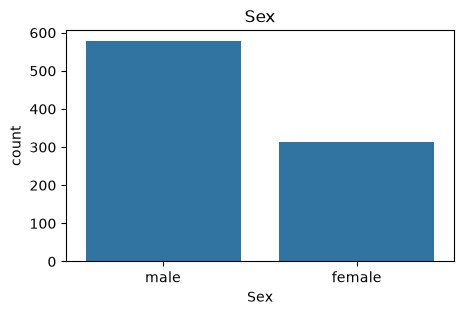

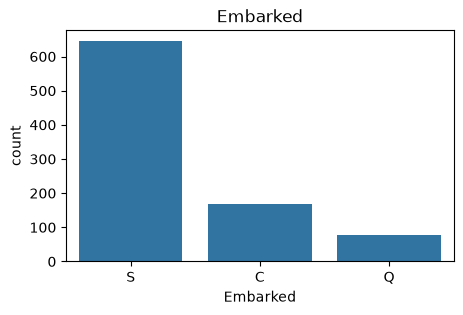

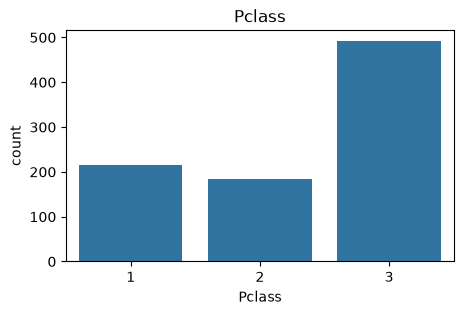

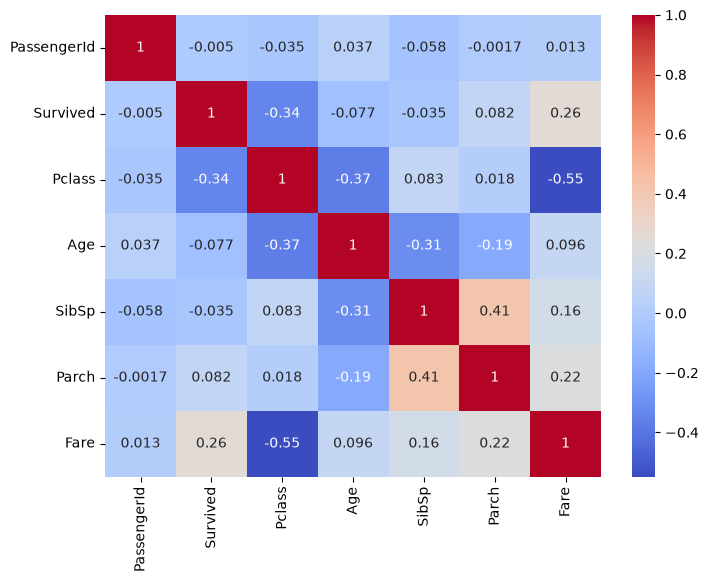

   PassengerId    Pclass       Age     SibSp     Parch      Fare  Sex_male  \
0            1  0.827377 -0.530377  0.432793 -0.473674 -0.502445      True   
1            2 -1.566107  0.571831  0.432793 -0.473674  0.786845     False   
2            3  0.827377 -0.254825 -0.474545 -0.473674 -0.488854     False   
3            4 -1.566107  0.365167  0.432793 -0.473674  0.420730     False   
4            5  0.827377  0.365167 -0.474545 -0.473674 -0.486337      True   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  

Titanic Dataset Preprocessing Completed Successfully.


In [14]:
#Q.10)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("Titanic-Dataset.csv")
print(df.isnull().sum())
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop('Cabin', axis=1, inplace=True)
df = df.drop_duplicates()
num_cols = ['Age','Fare','Pclass','SibSp','Parch']
for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.hist(df[col], bins=20, edgecolor='black')
    plt.title(col)
    plt.show()
cat_cols = ['Survived','Sex','Embarked','Pclass']
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(col)
    plt.show()
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()
df = pd.get_dummies(df,
                    columns=['Sex','Embarked'],
                    drop_first=True)
df = df.drop(columns=['Name','Ticket'], errors='ignore')
X = df.drop("Survived", axis=1)
X = X.select_dtypes(include=['int64','float64','bool'])
scaler = StandardScaler()
scale_cols = ['Age','Fare','SibSp','Parch','Pclass']
X[scale_cols] = scaler.fit_transform(X[scale_cols])
print(X.head())
print("\nTitanic Dataset Preprocessing Completed Successfully.")
